In [12]:
import pandas as pd

casino = pd.read_csv('Online_casino_DIB.csv')
casino['brand'] = 'casino'

sports = pd.read_csv('Online_sports_DIB.csv')
sports['brand'] = 'sports'

df = pd.concat([casino, sports], ignore_index=True)
df['ReqTimeUTC'] = pd.to_datetime(df['ReqTimeUTC'])


deposit_types = ['LOYALTYCARDDEBIT', 'LOYALTYCARDCREDITCL', 'LOYALTYCARDCREDITACH']
df['txn_direction'] = df['TransactionType'].apply(lambda x: 'deposit' if x in deposit_types else 'withdrawal')

print(df.shape)
print(df['brand'].value_counts())
print(df['txn_direction'].value_counts())
df.head()


(586781, 7)
brand
sports    447853
casino    138928
Name: count, dtype: int64
txn_direction
deposit       551123
withdrawal     35658
Name: count, dtype: int64


,ReqTimeUTC,TransactionType,TransactionAmount,Status,AccountIdentifier,brand,txn_direction
0,2019-07-05 05:02:28+00:00,LOYALTYCARDDEBIT,10.0,APPROVED,customer1734,casino,deposit
1,2019-07-05 05:26:00+00:00,LOYALTYCARDDEBIT,10.0,APPROVED,customer1734,casino,deposit
2,2019-07-05 04:54:35+00:00,LOYALTYCARDCREDITCL,10.0,APPROVED,customer1734,casino,deposit
3,2019-07-05 05:02:27+00:00,LOYALTYCARDCREDITCL,10.0,APPROVED,customer1734,casino,deposit
4,2019-07-05 05:25:59+00:00,LOYALTYCARDCREDITCL,10.0,APPROVED,customer1734,casino,deposit


In [11]:
deposits = df[df['txn_direction'] == 'deposit'].copy()

first_deposit = deposits.groupby('AccountIdentifier')['ReqTimeUTC'].min().reset_index()
first_deposit.columns = ['AccountIdentifier', 'first_deposit_date']
first_deposit['cohort_month'] = first_deposit['first_deposit_date'].dt.to_period('M')

deposits = deposits.merge(first_deposit[['AccountIdentifier', 'cohort_month']], on='AccountIdentifier')

deposits['txn_month'] = deposits['ReqTimeUTC'].dt.to_period('M')
deposits['cohort_index'] = (deposits['txn_month'] - deposits['cohort_month']).apply(lambda x: x.n)

print(first_deposit['cohort_month'].value_counts().sort_index())
deposits[['AccountIdentifier', 'cohort_month', 'txn_month', 'cohort_index']].head(10)


/tmp/ipykernel_760/1090607180.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_deposit['cohort_month'] = first_deposit['first_deposit_date'].dt.to_period('M')
/tmp/ipykernel_760/1090607180.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  deposits['txn_month'] = deposits['ReqTimeUTC'].dt.to_period('M')


cohort_month
2019-03    2300
2019-04     386
2019-05     280
2019-06     187
2019-07     153
2019-08     202
2019-09     409
2019-10     265
2019-11     650
2019-12     319
2020-01     272
2020-02     219
2020-03      12
Freq: M, Name: count, dtype: int64


,AccountIdentifier,cohort_month,txn_month,cohort_index
0,customer1734,2019-03,2019-07,4
1,customer1734,2019-03,2019-07,4
2,customer1734,2019-03,2019-07,4
3,customer1734,2019-03,2019-07,4
4,customer1734,2019-03,2019-07,4
5,customer1734,2019-03,2019-07,4
6,customer935,2019-11,2020-02,3
7,customer935,2019-11,2019-12,1
8,customer935,2019-11,2020-02,3
9,customer935,2019-11,2019-12,1


In [13]:
cohort_data = deposits.groupby(['cohort_month', 'cohort_index'])['AccountIdentifier'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='AccountIdentifier')

cohort_pivot = cohort_pivot.drop(index='2020-03', errors='ignore')

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

retention


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2019-03,100.0,71.1,63.0,57.9,53.4,59.0,67.8,68.0,53.3,52.6,51.3,47.3,17.4
2019-04,100.0,40.7,37.6,26.4,31.1,50.8,49.0,43.8,45.6,41.7,39.1,14.0,NaN
2019-05,100.0,40.4,27.5,30.7,46.1,43.2,43.2,42.1,41.8,38.6,12.9,NaN,NaN
2019-06,100.0,38.0,36.4,40.6,45.5,44.9,46.5,45.5,40.1,12.8,NaN,NaN,NaN
2019-07,100.0,38.6,46.4,51.0,45.1,45.1,39.2,37.9,11.8,NaN,NaN,NaN,NaN
2019-08,100.0,53.0,52.0,43.6,41.6,38.6,33.7,7.9,NaN,NaN,NaN,NaN,NaN
2019-09,100.0,61.1,39.4,32.5,32.8,28.9,5.9,NaN,NaN,NaN,NaN,NaN,NaN
2019-10,100.0,41.9,37.7,35.8,31.3,8.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-11,100.0,69.4,58.6,48.3,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


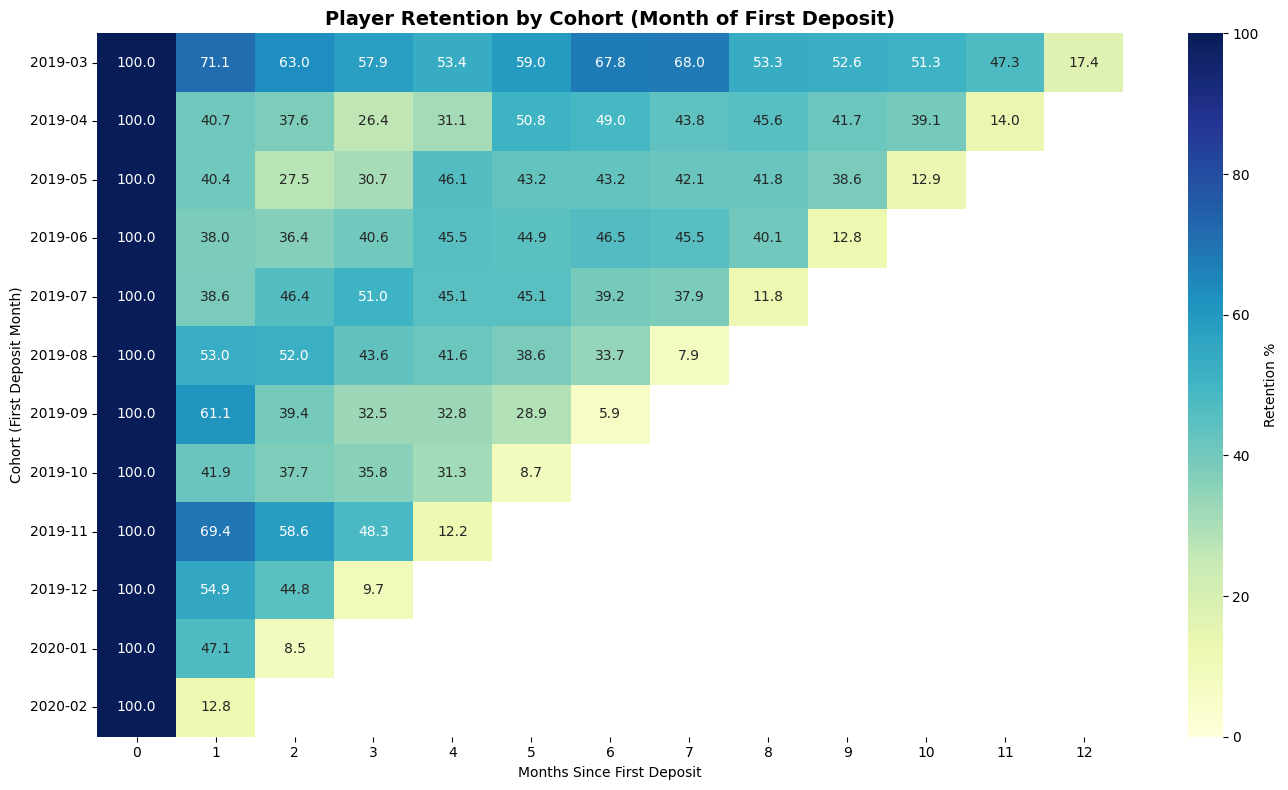

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100, cbar_kws={'label': 'Retention %'})
plt.title('Player Retention by Cohort (Month of First Deposit)', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Deposit')
plt.ylabel('Cohort (First Deposit Month)')
plt.tight_layout()
plt.savefig('retention_heatmap.png', dpi=150)
plt.show()


In [15]:
ltv_by_customer = deposits.groupby(['AccountIdentifier', 'brand'])['TransactionAmount'].sum().reset_index()
ltv_by_customer.columns = ['AccountIdentifier', 'brand', 'total_deposits']

print(ltv_by_customer.groupby('brand')['total_deposits'].describe())
# T-test
from scipy import stats
casino_ltv = ltv_by_customer[ltv_by_customer['brand']=='casino']['total_deposits']
sports_ltv = ltv_by_customer[ltv_by_customer['brand']=='sports']['total_deposits']

t_stat, p_value = stats.ttest_ind(casino_ltv, sports_ltv, equal_var=False)
print(f"\nT-statistic: {t_stat:.2f}, P-value: {p_value:.5f}")


         count         mean           std  min    25%       50%       75%  \
brand                                                                       
casino  2349.0  5262.690473  20832.092842  4.0  100.0   400.000  2000.000   
sports  5654.0  8408.432009  27672.033612  1.0  406.0  1382.675  5440.325   

              max  
brand              
casino  502180.93  
sports  752915.23  

T-statistic: -5.56, P-value: 0.00000


In [14]:
net_position = df.groupby(['AccountIdentifier', 'txn_direction'])['TransactionAmount'].sum().unstack(fill_value=0)
net_position['net_position'] = net_position['deposit'] - net_position['withdrawal']

print(net_position.head())
print(f"\nКлиентов с net_position < 0 (казино в минусе по ним): {(net_position['net_position'] < 0).sum()}")
print(f"Это {(net_position['net_position'] < 0).mean()*100:.1f}% от всех клиентов")

txn_direction        deposit  withdrawal  net_position
AccountIdentifier                                     
customer1          105502.21     1700.00     103802.21
customer10         115387.21       60.00     115327.21
customer100         10591.39        0.00      10591.39
customer1000        14376.01       26.12      14349.89
customer1001       103674.10      349.00     103325.10

Клиентов с net_position < 0 (казино в минусе по ним): 126
Это 2.2% от всех клиентов


In [16]:
early_activity = deposits[deposits['cohort_index'].between(0, 2)].groupby('AccountIdentifier')['TransactionAmount'].sum()
later_activity = deposits[deposits['cohort_index'].between(3, 5)].groupby('AccountIdentifier')['TransactionAmount'].sum()

escalation = pd.DataFrame({'early_3mo': early_activity, 'later_3mo': later_activity}).fillna(0)

escalation['escalation_ratio'] = escalation['later_3mo'] / escalation['early_3mo']

flagged = escalation[escalation['escalation_ratio'] >= 2]
print(f"Clients with escalation signs (deposit growth of 2+ times): {len(flagged)}")
print(f"This is {len(flagged)/len(escalation)*100:.1f}% from clients who were active in both periods")
escalation.sort_values('escalation_ratio', ascending=False).head(10)


Clients with escalation signs (deposit growth of 2+ times): 586
This is 10.4% from clients who were active in both periods


,early_3mo,later_3mo,escalation_ratio
AccountIdentifier,,,
customer704,20.0,7235.78,361.789000
customer376,74.9,19328.04,258.051268
customer1861,40.0,9948.28,248.707000
customer1501,40.0,9687.09,242.177250
customer1563,40.0,9076.50,226.912500
customer1549,40.0,8931.97,223.299250
customer885,60.0,12951.38,215.856333
customer2188,50.0,9510.48,190.209600
customer1896,45.0,7272.65,161.614444
